In [7]:
import numpy as np 
import pandas as pd 

df = pd.read_csv('mall_customers.csv')
df.head(

)



,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Female,22,29.0,76.7
1,2,Male,35,23.9,65.0
2,3,Male,45,30.2,76.4
3,4,Male,59,37.2,78.1
4,5,Male,39,23.1,67.9


In [13]:
from sklearn.cluster import DBSCAN
import numpy as np
from sklearn.preprocessing import StandardScaler

X = df[['Annual Income (k$)', 'Spending Score (1-100)']].values

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

n_clusters   = len(set(labels)) - (1 if -1 in labels else 0)
n_noise      = list(labels).count(-1)
unique_labels = sorted(set(labels))

print(f"DBSCAN Parameters : eps=0.5, min_samples=5")
print(f"Clusters found    : {n_clusters}")
print(f"Noise points      : {n_noise}")
print(f"Labels assigned   : {unique_labels}")
print(f"Total points      : {len(labels)}")

DBSCAN Parameters : eps=0.5, min_samples=5
Clusters found    : 1
Noise points      : 7
Labels assigned   : [np.int64(-1), np.int64(0)]
Total points      : 200


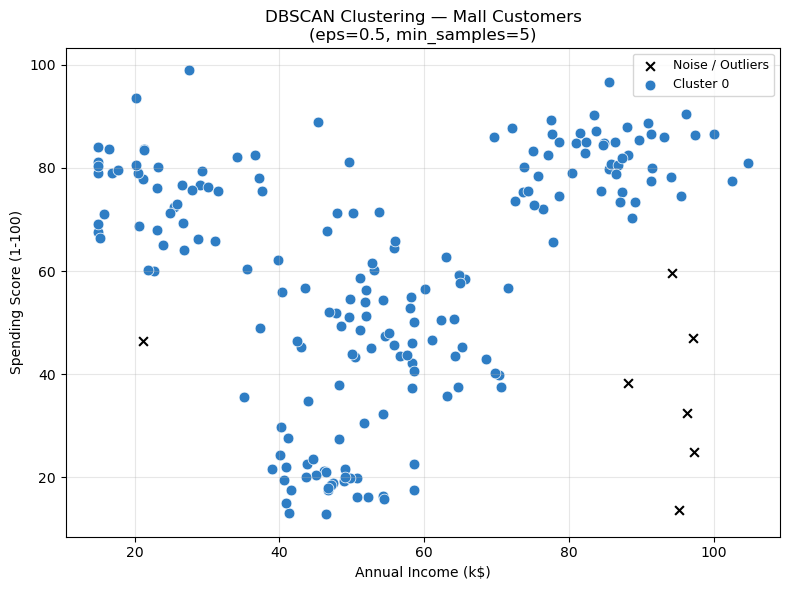

In [17]:


import matplotlib.pyplot as plt

dbscan = DBSCAN(eps=0.5, min_samples=5)
labels = dbscan.fit_predict(X_scaled)

unique_labels = sorted(set(labels))
colors = ['#2E7DC4','#1D9E75','#E8554E','#F4A229','#534AB7',
          '#D4537E','#BA7517','#56B4D3']

plt.figure(figsize=(8, 6))

for label in unique_labels:
    mask = labels == label
    if label == -1:
        plt.scatter(X[mask, 0], X[mask, 1],
                    c='black', s=40, marker='x',
                    label='Noise / Outliers', zorder=5, linewidths=1.5)
    else:
        plt.scatter(X[mask, 0], X[mask, 1],
                    c=colors[label % len(colors)],
                    s=60, edgecolors='white', linewidths=0.5,
                    label=f'Cluster {label}')

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.title('DBSCAN Clustering — Mall Customers\n(eps=0.5, min_samples=5)')
plt.legend(loc='upper right', fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
from sklearn.cluster import DBSCAN

configs = [
    {'eps': 0.3, 'min_samples': 3},
    {'eps': 0.5, 'min_samples': 5},
    {'eps': 0.8, 'min_samples': 5},
    {'eps': 1.0, 'min_samples': 10},
]

print(f"{'eps':>6} {'min_samples':>12} {'Clusters':>10} {'Noise':>8}")
print("-" * 42)

for cfg in configs:
    db = DBSCAN(eps = cfg['eps'] , min_samples = cfg['min_samples'])
    lbl = db.fit_predict(X_scaled)
    n_c = len(set(lbl)) - (1 if -1 in lbl else 0)
    n_n = list(lbl).count(-1)
    print(f"{cfg['eps']:>6} {cfg['min_samples']:>12} {n_c:>10} {n_n:>8}")

   eps  min_samples   Clusters    Noise
------------------------------------------
   0.3            3          3       14
   0.5            5          1        7
   0.8            5          1        1
   1.0           10          1        1


make_moons — Clusters: 2  Noise points: 0
Noise point indices: []


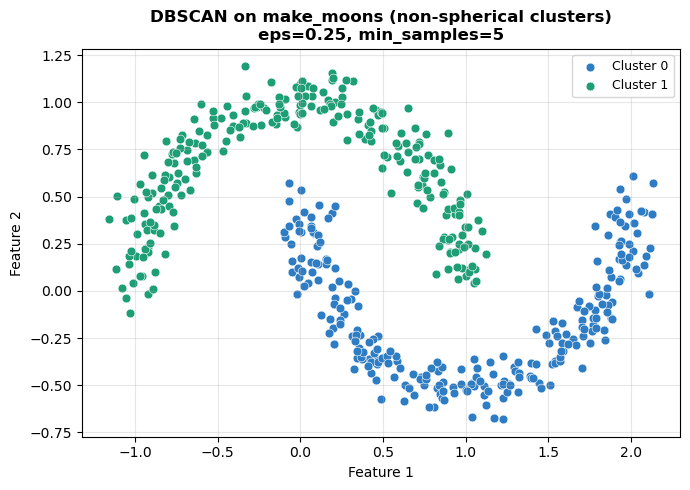

In [25]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.datasets import make_moons , make_circles 
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler 

X_moons , y_moons = make_moons(n_samples = 500 , noise = 0.08 , random_state = 42)

scaler_m = StandardScaler()
X_moons_s = scaler.fit_transform(X_moons)

db_moons = DBSCAN(eps= 0.25 , min_samples = 5)
labels_moons =db_moons.fit_predict(X_moons_s)

noise_indices = np.where(labels_moons == -1)[0]
n_clusters_m  = len(set(labels_moons)) - (1 if -1 in labels_moons else 0)

print(f"make_moons — Clusters: {n_clusters_m}  Noise points: {len(noise_indices)}")
print(f"Noise point indices: {noise_indices.tolist()}")

plt.figure(figsize=(7, 5))
colors = ['#2E7DC4','#1D9E75','#E8554E']

for label in sorted(set(labels_moons)):
    mask = labels_moons == label
    if label == -1:
        plt.scatter(X_moons[mask,0], X_moons[mask,1],
                    c='black', s=60, marker='x', zorder=5,
                    linewidths=2, label=f'Noise ({len(noise_indices)} pts)')
    else:
        plt.scatter(X_moons[mask,0], X_moons[mask,1],
                    c=colors[label % len(colors)], s=40,
                    edgecolors='white', linewidths=0.4,
                    label=f'Cluster {label}')

plt.title('DBSCAN on make_moons (non-spherical clusters)\neps=0.25, min_samples=5',
          fontweight='bold')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend(fontsize=9)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()